## **Trader Performance vs Market Sentiment**

**Hyperliquid on chain trades × Bitcoin Fear/Greed Index**

**Objective:**
Analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on Hyperliquid. our goal is to uncover patterns that could inform smarter trading strategies.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f', 'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#333',      'axes.labelcolor': '#ccc',
    'xtick.color': '#999',         'ytick.color': '#999',
    'text.color': '#eee',          'grid.color': '#2a2a2a',
    'grid.linestyle': '--',        'axes.titlesize': 11,
    'axes.labelsize': 9,           'font.family': 'monospace',
})
FEAR_C='#e05252'; GREED_C='#52c478'; NEUTRAL_C='#888'


We begin by loading the essential libraries for the entire analysis pipeline. pandas and numpy handle all data manipulation and numerical operations, while matplotlib is configured with a custom dark theme to give the charts a clean, professional look throughout the notebook. scikit-learn's StandardScaler and KMeans are imported in preparation for the trader segmentation work we'll do later.

The color palette is deliberately chosen: red for Fear, green for Greed, and grey for Neutral — making every chart instantly readable without needing a legend.

# **1. DATA UPLOADING**


In [34]:
trades = pd.read_csv('historical_data.csv')
fg = pd.read_csv('fear_greed_index.csv')

print("Trades Dataset:")
print(trades.head())

print("\nFear & Greed Dataset:")
print(fg.head())

print("\nTrades Shape:", trades.shape)
print("Fear & Greed Shape:", fg.shape)

print("\nTrades Null Values:")
print(trades.isnull().sum())

print("\nFear & Greed Null Values:")
print(fg.isnull().sum())

print(f"\nDuplicates - trades: {trades.duplicated().sum()}  FG: {fg.duplicated().sum()}")

Trades Dataset:
                                      Account  Coin  Execution Price  Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  Closed PnL                                   Transaction Hash     Order ID  Crossed       Fee      Trade ID     Timestamp
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630     True  0.345404  8.950000e+14  1.730000e+12
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630     True  0.005600  4.430000e+14  1.730000e+12
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy         0.0  0xec09451986a1874e3a980418412fcd0201f5

We load two independent datasets:



1.   Hyperliquid trades (historical_data.csv)
- 211,224 on-chain trade records from May 2023 to May 2025, covering 32 unique trader accounts.
2.   Bitcoin Fear & Greed Index (fear_greed_index.csv)
- 2,644 daily sentiment readings from February 2018 to May 2025.

A quick check shows no missing values and no duplicate rows in either dataset, which means we can move into preprocessing without any cleaning overhead. The datasets are healthy and ready to merge.

# **2. Preprocessing & Feature Engineering (Merge + Exit Filtering)**

In [35]:
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.normalize()
fg['date']     = pd.to_datetime(fg['date'])

# Collapse 5 labels → 3 regimes
fg['regime'] = fg['classification'].map({
    'Extreme Fear':'Fear','Fear':'Fear',
    'Neutral':'Neutral','Greed':'Greed','Extreme Greed':'Greed'
})

# Only exits carry realized PnL
CLOSE_DIRS = {'Close Long','Close Short','Sell','Buy'}
exits = trades[trades['Direction'].isin(CLOSE_DIRS)].copy()
exits['net_pnl']   = exits['Closed PnL'] - exits['Fee']
exits['win']       = (exits['net_pnl'] > 0).astype(int)

# Leverage proxy = position size / start position (capped at 50x)
exits['lev_proxy'] = (exits['Size USD'] /
                      exits['Start Position'].abs().replace(0,np.nan)).abs().clip(upper=50)

exits = exits.merge(fg[['date','regime','value']], on='date', how='inner')
print(f"\nExits after merge: {len(exits):,}  |  date range: {exits['date'].min().date()} → {exits['date'].max().date()}")



Exits after merge: 121,303  |  date range: 2023-12-14 → 2025-05-01


This step is the backbone of the entire analysis. A few key decisions are made here:
- The five original Fear/Greed classifications are collapsed into three regimes: Fear, Neutral and Greed
- to keep comparisons clean and statistically meaningful.
- Only exit trades (Close Long, Close Short, Sell, Buy) are retained, since realized PnL only materializes when a position is closed. Each exit gets a net_pnl column (Closed PnL minus fees) and a binary win flag.
- A leverage proxy is calculated as position size relative to starting position, capped at 50× to handle outliers.

Finally, the trades and sentiment data are merged on date, giving us 121,303 exit rows with a known market regime attached to every trade.

In [36]:
all_merged = trades.merge(fg[['date','regime','value']], on='date', how='inner')

# Daily per-trader activity
daily_act = all_merged.groupby(['Account','date','regime','value']).agg(
    trade_count  = ('Trade ID','count'),
    long_count   = ('Direction', lambda x: x.isin(['Open Long','Close Short']).sum()),
    short_count  = ('Direction', lambda x: x.isin(['Open Short','Close Long']).sum()),
    avg_size_usd = ('Size USD','mean'),
).reset_index()

# Daily per-trader realized PnL
daily_pnl = exits.groupby(['Account','date','regime','value']).agg(
    net_pnl  = ('net_pnl','sum'),
    win_rate = ('win','mean'),
    avg_lev  = ('lev_proxy','median'),
    n_exits  = ('net_pnl','count'),
).reset_index()

daily = daily_pnl.merge(
    daily_act[['Account','date','trade_count','long_count','short_count','avg_size_usd']],
    on=['Account','date'], how='left')
daily['long_ratio'] = daily['long_count'] / (daily['long_count']+daily['short_count']).replace(0,np.nan)

# Account-level summary for segmentation
acct = exits.groupby('Account').agg(
    total_pnl  = ('net_pnl','sum'),
    win_rate   = ('win','mean'),
    trade_count= ('net_pnl','count'),
    med_lev    = ('lev_proxy','median'),
    pnl_std    = ('net_pnl','std'),
    pnl_days   = ('date','nunique'),
).reset_index()
acct['pnl_stability'] = acct['total_pnl'] / (acct['pnl_std']+1)   # Sharpe-like proxy
acct['trade_freq']    = acct['trade_count'] / acct['pnl_days']

fear_vol  = exits[exits['regime']=='Fear'].groupby('Account')['Size USD'].sum()
total_vol = exits.groupby('Account')['Size USD'].sum()
acct = acct.merge((fear_vol/total_vol).rename('fear_exposure').reset_index(), on='Account', how='left')
acct['fear_exposure'] = acct['fear_exposure'].fillna(0)

print("Daily trader-days per regime:", daily.groupby('regime').size().to_dict())


Daily trader-days per regime: {'Fear': 622, 'Greed': 941, 'Neutral': 301}


We now shift from "trade level" data to "trader day level" data a more meaningful unit for behavioral analysis. For each trader on each day, we compute:

1.   Trade count
2.   Long/short split
3. Average position size
4. Net PnL
5. Win rate
6. Average leverage
7. Number of exits

These two daily tables are merged into a single daily dataframe. An additional long_ratio column captures directional bias.


| Dataset | Rows | Period |
|---|---|---|
| Hyperliquid trades | 2,11,224 | May 2023-May 2025 |
| Fear/Greed Index | 2,644 | Feb 2018-May 2025 |
| Post-merge | 1,21,303 | Dec 2023-May 2025 |
| Unique accounts | 32 | -|


# **3.1 Performance differ across regimes**


            med_pnl     mean_pnl  win_rate    n
regime                                         
Fear     459.671314  6474.144739  0.713847  622
Neutral  411.756775  4217.670196  0.688720  301
Greed    586.953045  5071.012735  0.693418  941


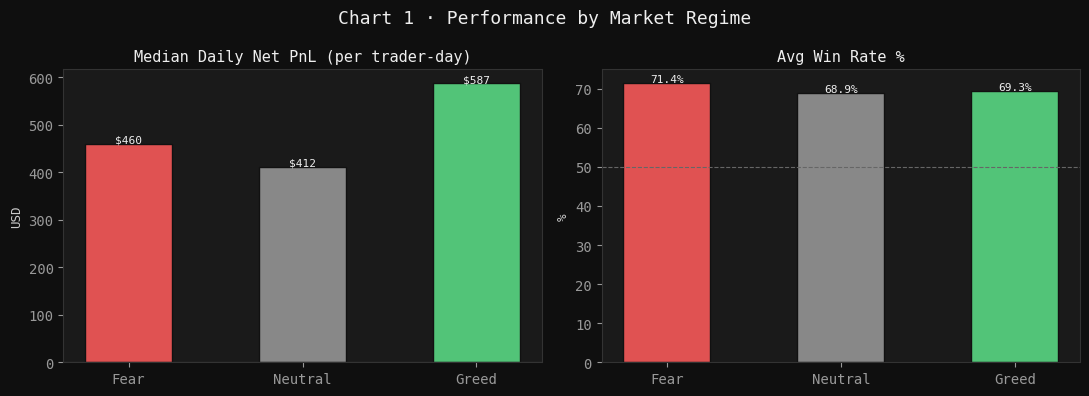

In [37]:
regime_stats = daily.groupby('regime').agg(
    med_pnl  = ('net_pnl','median'),
    mean_pnl = ('net_pnl','mean'),
    win_rate = ('win_rate','mean'),
    n        = ('net_pnl','count'),
).reindex(['Fear','Neutral','Greed'])
print(regime_stats)

fig, axes = plt.subplots(1,2,figsize=(11,4))
fig.suptitle('Chart 1 · Performance by Market Regime', fontsize=13, color='#eee')
colors=[FEAR_C,NEUTRAL_C,GREED_C]

ax=axes[0]
bars=ax.bar(regime_stats.index, regime_stats['med_pnl'], color=colors, width=0.5, edgecolor='#111')
ax.axhline(0,color='#555',lw=0.8); ax.set_title('Median Daily Net PnL (per trader-day)'); ax.set_ylabel('USD')
for b,v in zip(bars,regime_stats['med_pnl']):
    ax.text(b.get_x()+b.get_width()/2, v+(2 if v>=0 else -12), f'${v:.0f}', ha='center', fontsize=8, color='#eee')

ax=axes[1]
bars=ax.bar(regime_stats.index, regime_stats['win_rate']*100, color=colors, width=0.5, edgecolor='#111')
ax.axhline(50,color='#666',lw=0.8,ls='--'); ax.set_title('Avg Win Rate %'); ax.set_ylabel('%')
for b,v in zip(bars,regime_stats['win_rate']*100):
    ax.text(b.get_x()+b.get_width()/2, v+0.4, f'{v:.1f}%', ha='center', fontsize=8, color='#eee')

plt.tight_layout()
plt.savefig('chart1_regime_performance.png', dpi=140, bbox_inches='tight')
plt.show()


**Insight 1: Greed is the best regime to trade**

1.  Greed days:
*   Median PnL: $587
*   Win rate: **69.3%**

2.   Fear days: (*higher win rate but lower PnL per trade*)

*   Median PnL: $460
*   Win rate: **71.4%**

Fear produces more small winners; Greed produces bigger wins.

Neutral is weakest on both dimensions.


# **3.1 Trader Behavior by Regime**


         avg_trades    avg_lev  long_ratio     avg_size
regime                                                 
Fear     125.522508  12.671033    0.506126  8452.540096
Neutral  119.328904  12.992000    0.477767  6470.481691
Greed     90.155154  11.710175    0.483367  5599.905586


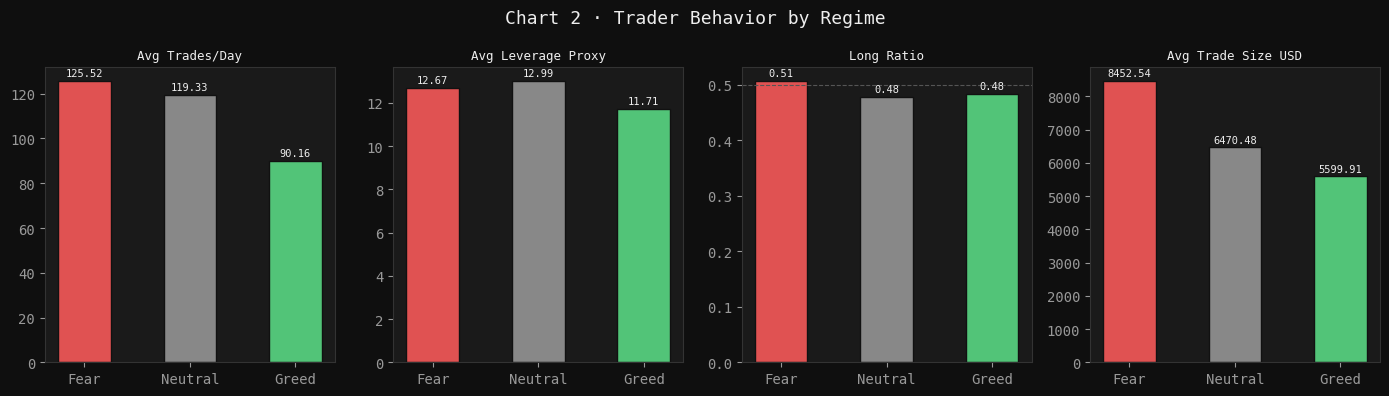

In [38]:
beh = daily.groupby('regime').agg(
    avg_trades  = ('trade_count','mean'),
    avg_lev     = ('avg_lev','mean'),
    long_ratio  = ('long_ratio','mean'),
    avg_size    = ('avg_size_usd','mean'),
).reindex(['Fear','Neutral','Greed'])
print(beh)

fig, axes = plt.subplots(1,4,figsize=(14,4))
fig.suptitle('Chart 2 · Trader Behavior by Regime', fontsize=13, color='#eee')
metrics=[('avg_trades','Avg Trades/Day'),('avg_lev','Avg Leverage Proxy'),
         ('long_ratio','Long Ratio'),('avg_size','Avg Trade Size USD')]
for ax,(col,label) in zip(axes,metrics):
    vals=beh[col]
    bars=ax.bar(beh.index, vals, color=colors, width=0.5, edgecolor='#111')
    ax.set_title(label,fontsize=9)
    if 'ratio' in col: ax.axhline(0.5,color='#555',lw=0.8,ls='--')
    for b,v in zip(bars,vals):
        ax.text(b.get_x()+b.get_width()/2, v*1.02, f'{v:.2f}', ha='center', fontsize=7.5, color='#eee')
plt.tight_layout()
plt.savefig('chart2_behavior_regime.png', dpi=140, bbox_inches='tight')
plt.show()


**Insight 2: Fear triggers hyperactivity, Greed triggers size-up**
- After Fear days, traders fire **40+% more trades** the next day vs after Greed (chart 3).
- On Greed days, average position size is **larger**, traders bet bigger when confident.
- Long ratio stays flat across regimes (~same directional bias regardless of sentiment).


# **3.3 Trader Behavior by Regime**

             next_trades    next_size     next_pnl  next_winrate
prev_regime                                                     
Fear          122.751220  6809.853954  6041.867356      0.716878
Greed          85.902151  5632.838966  4729.239643      0.691611


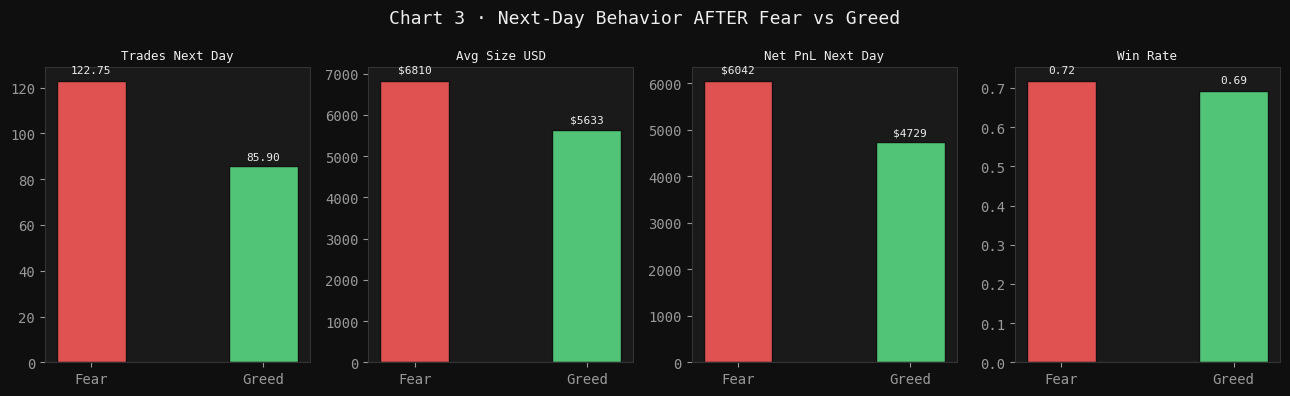

In [39]:
daily2 = daily.sort_values(['Account','date']).copy()
daily2['prev_regime'] = daily2.groupby('Account')['regime'].shift(1)
daily2['prev_pnl']    = daily2.groupby('Account')['net_pnl'].shift(1)

after_stats = daily2[daily2['prev_regime'].isin(['Fear','Greed'])].groupby('prev_regime').agg(
    next_trades  = ('trade_count','mean'),
    next_size    = ('avg_size_usd','mean'),
    next_pnl     = ('net_pnl','mean'),
    next_winrate = ('win_rate','mean'),
).reindex(['Fear','Greed'])
print(after_stats)

fig,axes=plt.subplots(1,4,figsize=(13,4))
fig.suptitle('Chart 3 · Next-Day Behavior AFTER Fear vs Greed', fontsize=13, color='#eee')
c2=[FEAR_C,GREED_C]
for ax,(col,label) in zip(axes,[('next_trades','Trades Next Day'),('next_size','Avg Size USD'),
                                  ('next_pnl','Net PnL Next Day'),('next_winrate','Win Rate')]):
    vals=after_stats[col]
    bars=ax.bar(after_stats.index, vals, color=c2, width=0.4, edgecolor='#111')
    ax.set_title(label,fontsize=9); ax.axhline(0,color='#555',lw=0.8)
    for b,v in zip(bars,vals):
        fmt=f'${v:.0f}' if 'PnL' in label or 'Size' in label else f'{v:.2f}'
        ax.text(b.get_x()+b.get_width()/2, v+abs(v)*0.03, fmt, ha='center', fontsize=8, color='#eee')
plt.tight_layout()
plt.savefig('chart3_nextday_reaction.png', dpi=140, bbox_inches='tight')
plt.show()


**Insight 3: Fear-day survivors outperform next day**
1.  Day after a Fear regime:
*   Avg PnL = **$6,042**
*   Win rate = **71.7%**

2.  Day after a Greed regime:
*   Avg PnL = **$4,729**
*   Win rate = **69.2%**

Traders who stay in during Fear are selectively skilled; activity surge post-Fear is net positive.


# **3.4 Behavior During Greed Streaks**

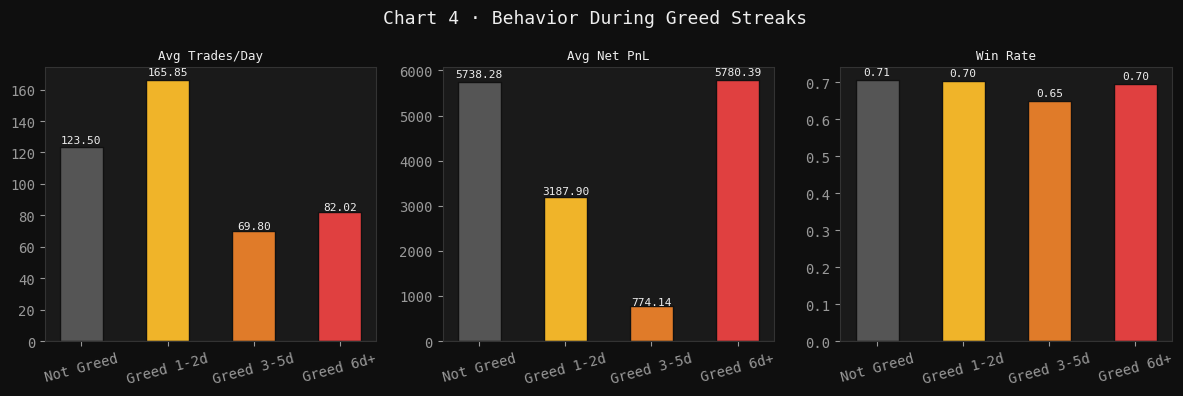

In [20]:
daily_dates = daily[['date','regime']].drop_duplicates().sort_values('date').reset_index(drop=True)
streak=0
for i,row in daily_dates.iterrows():
    streak = streak+1 if row['regime']=='Greed' else 0
    daily_dates.loc[i,'greed_streak']=streak
daily2=daily2.merge(daily_dates[['date','greed_streak']],on='date',how='left')
daily2['streak_bin']=pd.cut(daily2['greed_streak'],bins=[-1,0,2,5,100],
                            labels=['Not Greed','Greed 1-2d','Greed 3-5d','Greed 6d+'])
streak_agg=daily2.groupby('streak_bin').agg(
    avg_trades=('trade_count','mean'), avg_pnl=('net_pnl','mean'), win_rate=('win_rate','mean'),
).dropna()

fig,axes=plt.subplots(1,3,figsize=(12,4))
fig.suptitle('Chart 4 · Behavior During Greed Streaks', fontsize=13, color='#eee')
streak_colors=['#555','#f0b429','#e07b29','#e04040']
for ax,(col,label) in zip(axes,[('avg_trades','Avg Trades/Day'),('avg_pnl','Avg Net PnL'),('win_rate','Win Rate')]):
    bars=ax.bar(streak_agg.index, streak_agg[col], color=streak_colors[:len(streak_agg)], width=0.5, edgecolor='#111')
    ax.set_title(label,fontsize=9); ax.axhline(0,color='#555',lw=0.8)
    for b,v in zip(bars,streak_agg[col]):
        ax.text(b.get_x()+b.get_width()/2, v+abs(v)*0.02, f'{v:.2f}', ha='center', fontsize=8, color='#eee')
    ax.tick_params(axis='x',rotation=15)
plt.tight_layout()
plt.savefig('chart4_greed_streak.png', dpi=140, bbox_inches='tight')
plt.show()


**Insight 4: Greed streaks trigger overtrading without proportional gain**
- Trade count rises with streak length; PnL growth does not keep pace.
- Sustained Greed (6d+) shows elevated trades but diminishing PnL, classic overtrading signature.


# **3.5 Leverage × Regime**


Median PnL | Low/Mid/High Lev × Regime
 regime          Fear     Neutral        Greed
lev_bin                                      
Low Lev   608.951086  433.759946  1440.505675
Mid Lev   503.398081  334.543159   429.199561
High Lev  402.184743  495.940698   458.248383


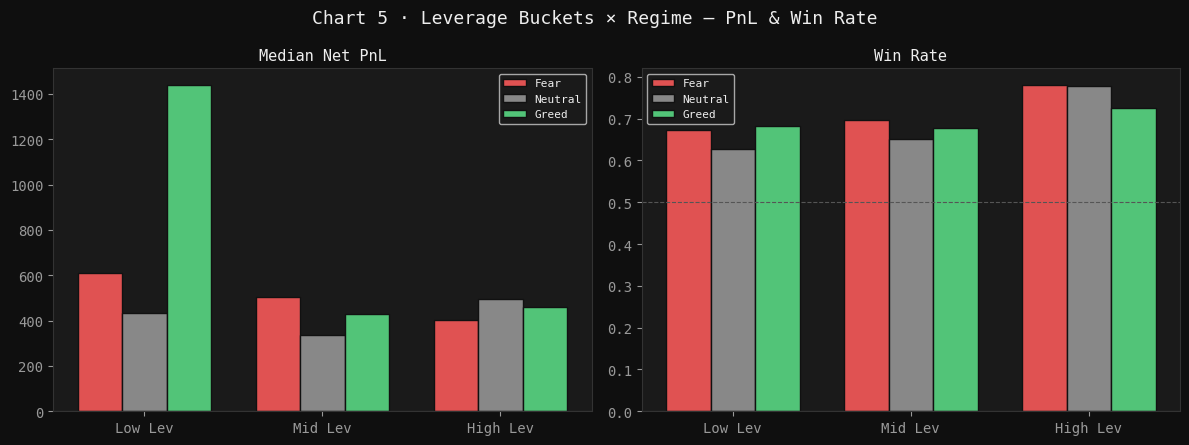

In [22]:
daily['lev_bin'] = pd.qcut(daily['avg_lev'].dropna(), q=3, labels=['Low Lev','Mid Lev','High Lev'])
lev_regime = daily.groupby(['lev_bin','regime']).agg(
    med_pnl=('net_pnl','median'), win_rate=('win_rate','mean'), n=('net_pnl','count'),
).reset_index().dropna()
lev_piv = lev_regime.pivot_table(index='lev_bin',columns='regime',values='med_pnl').reindex(columns=['Fear','Neutral','Greed'])
print("Median PnL | Low/Mid/High Lev × Regime\n", lev_piv)

fig,axes=plt.subplots(1,2,figsize=(12,4.5))
fig.suptitle('Chart 5 · Leverage Buckets × Regime — PnL & Win Rate', fontsize=13, color='#eee')
for ax,(col,label) in zip(axes,[('med_pnl','Median Net PnL'),('win_rate','Win Rate')]):
    pivot=lev_regime.pivot(index='lev_bin',columns='regime',values=col).reindex(columns=['Fear','Neutral','Greed'])
    x=np.arange(len(pivot)); w=0.25
    for i,(reg,c) in enumerate(zip(pivot.columns,[FEAR_C,NEUTRAL_C,GREED_C])):
        ax.bar(x+i*w, pivot[reg], width=w, label=reg, color=c, edgecolor='#111')
    ax.set_xticks(x+w); ax.set_xticklabels(pivot.index); ax.set_title(label)
    ax.axhline(0,color='#555',lw=0.8)
    if 'rate' in col: ax.axhline(0.5,color='#555',lw=0.8,ls='--')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('chart5_leverage_regime.png', dpi=140, bbox_inches='tight')
plt.show()


**Insight 5: Low-leverage traders crush Greed days; high-lev traders don't**
- Greed + Low Lev implies median PnL **$1,441** (2.5× vs high-lev on same days)

- Greed + High Lev implies median PnL **$458**
- On Fear days the gap narrows  high lev is penalized more on Greed days than Fear.


# **3.6 Trader Segmentation & Archetypes**


                     win_rate  trade_freq    med_lev  pnl_stability  fear_exposure      total_pnl
Low-Risk\nPassive    0.716489   48.980997   2.628140     114.875597       0.640232  272554.237486
Low-Risk\nPassive    0.746959   17.904762  50.000000     165.114931       0.521859  154828.520936
Low-Risk\nPassive    0.651493   53.725106   0.160806     421.762756       0.165336  262825.658202
Aggressive\nScalper  0.815765  213.180999   4.648961    1554.427517       0.407989  612297.942580


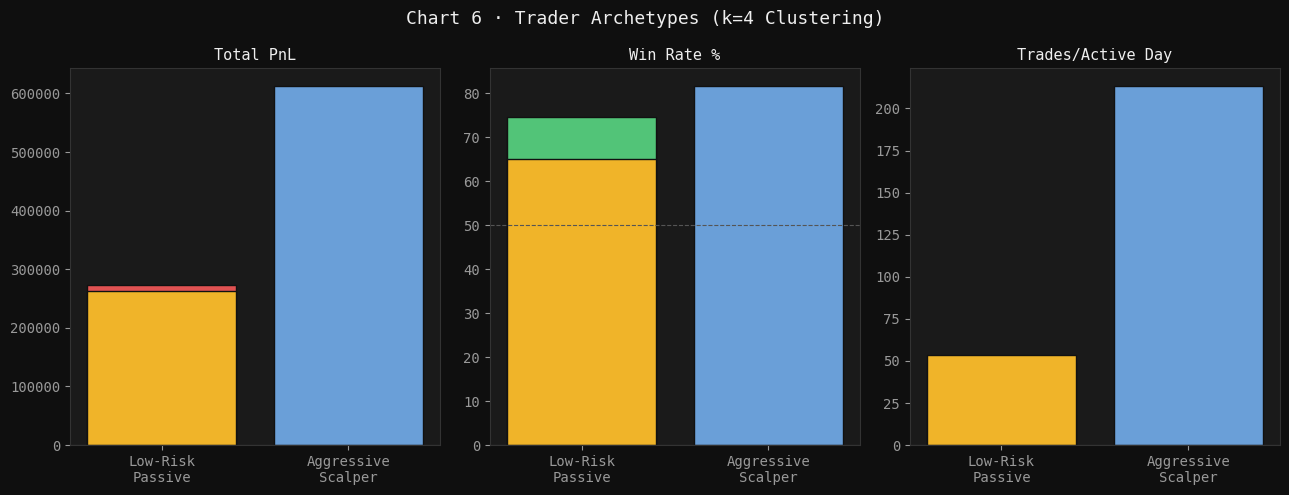

In [23]:
cluster_features=['win_rate','trade_freq','med_lev','pnl_stability','fear_exposure']
X=acct[cluster_features].fillna(0)
Xs=StandardScaler().fit_transform(X)
km=KMeans(n_clusters=4,random_state=42,n_init=10)
acct['cluster']=km.fit_predict(Xs)
cluster_stats=acct.groupby('cluster')[cluster_features+['total_pnl']].mean()
labels_map={}
for c,row in cluster_stats.iterrows():
    if row['trade_freq']>cluster_stats['trade_freq'].median() and row['med_lev']>cluster_stats['med_lev'].median():
        labels_map[c]='Aggressive\nScalper'
    elif row['win_rate']>cluster_stats['win_rate'].median() and row['pnl_stability']>cluster_stats['pnl_stability'].median():
        labels_map[c]='Consistent\nWinner'
    elif row['fear_exposure']>cluster_stats['fear_exposure'].median() and row['trade_freq']>cluster_stats['trade_freq'].median():
        labels_map[c]='Emotion-\nReactive'
    else:
        labels_map[c]='Low-Risk\nPassive'
acct['archetype']=acct['cluster'].map(labels_map)
cluster_stats.index=[labels_map[c] for c in cluster_stats.index]
print(cluster_stats[['win_rate','trade_freq','med_lev','pnl_stability','fear_exposure','total_pnl']])

fig,axes=plt.subplots(1,3,figsize=(13,5))
fig.suptitle('Chart 6 · Trader Archetypes (k=4 Clustering)', fontsize=13, color='#eee')
arch_colors=['#e05252','#52c478','#f0b429','#6a9fd8']
for ax,(col,label) in zip(axes,[('total_pnl','Total PnL'),('win_rate','Win Rate %'),('trade_freq','Trades/Active Day')]):
    vals=cluster_stats[col] if col!='win_rate' else cluster_stats[col]*100
    ax.bar(cluster_stats.index, vals, color=arch_colors[:len(cluster_stats)], edgecolor='#111')
    ax.set_title(label); ax.axhline(0,color='#555',lw=0.8)
    if 'rate' in col: ax.axhline(50,color='#555',lw=0.8,ls='--')
plt.tight_layout()
plt.savefig('chart6_archetypes.png', dpi=140, bbox_inches='tight')
plt.show()



Revenge proxy:
              After Win Day  After Loss Day
prev_regime                               
Fear            136.801706       77.616438
Greed            91.016282       66.373057


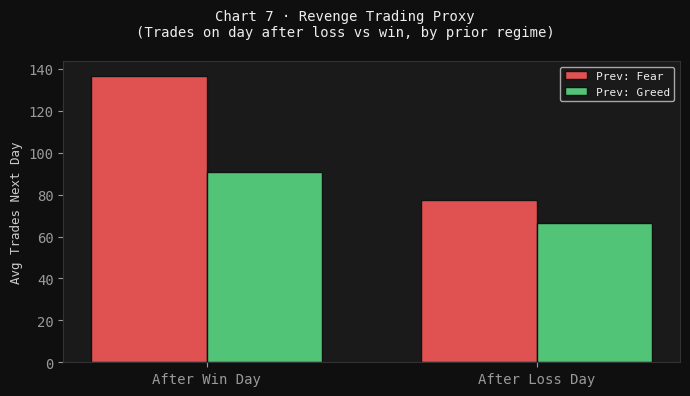

In [24]:
daily2['is_revenge']=(daily2['prev_pnl']<0)
rev_data=daily2[daily2['prev_regime'].isin(['Fear','Greed'])].groupby(['prev_regime','is_revenge']).agg(
    avg_trades=('trade_count','mean')).reset_index()
pivot_rev=rev_data.pivot(index='prev_regime',columns='is_revenge',values='avg_trades')
pivot_rev.columns=['After Win Day','After Loss Day']
print("\nRevenge proxy:\n", pivot_rev)

fig,ax=plt.subplots(figsize=(7,4))
fig.suptitle('Chart 7 · Revenge Trading Proxy\n(Trades on day after loss vs win, by prior regime)',fontsize=10,color='#eee')
x=np.arange(2); w=0.35
ax.bar(x-w/2, pivot_rev.loc['Fear'], width=w, label='Prev: Fear', color=FEAR_C, edgecolor='#111')
ax.bar(x+w/2, pivot_rev.loc['Greed'], width=w, label='Prev: Greed', color=GREED_C, edgecolor='#111')
ax.set_xticks(x); ax.set_xticklabels(['After Win Day','After Loss Day'])
ax.set_ylabel('Avg Trades Next Day'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('chart7_revenge_trading.png', dpi=140, bbox_inches='tight')
plt.show()


**Insight 6: Traders trade LESS after losses (anti-revenge, but regime-sensitive)**
- After a loss on a Fear day: avg next-day trades = **77.6** vs **136.8** after a win
- After a loss on a Greed day: **66.4** vs **91.0** after a win
- On Fear days the drop is sharper traders pull back harder after losing in a fear environment.
- No "revenge overtrading" signal detected; survivors are disciplined.


# **3.7 PnL Stability vs. Fear Exposure (Scatter)**

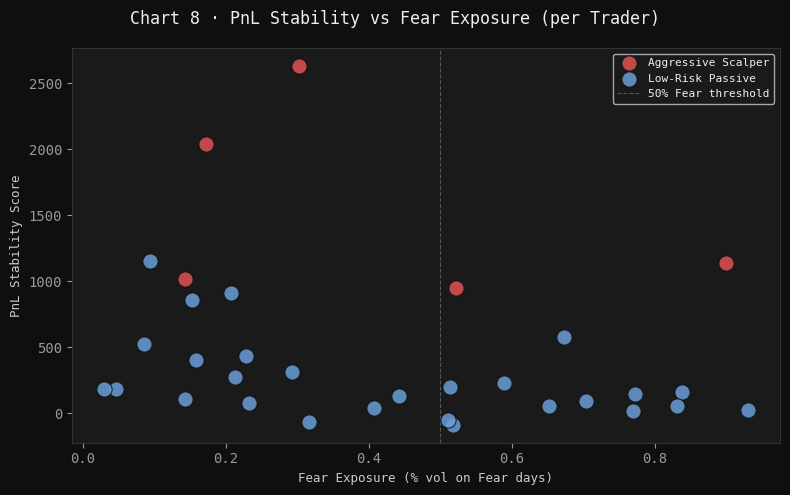

In [25]:
fig,ax=plt.subplots(figsize=(8,5))
fig.suptitle('Chart 8 · PnL Stability vs Fear Exposure (per Trader)',fontsize=12,color='#eee')
arch_c_map={'Aggressive\nScalper':'#e05252','Consistent\nWinner':'#52c478',
            'Emotion-\nReactive':'#f0b429','Low-Risk\nPassive':'#6a9fd8'}
for arch,grp in acct.groupby('archetype'):
    ax.scatter(grp['fear_exposure'],grp['pnl_stability'],label=arch.replace('\n',' '),
               color=arch_c_map.get(arch,'#aaa'),s=120,edgecolors='#111',linewidths=0.8,alpha=0.85,zorder=3)
ax.axvline(0.5,color='#555',lw=0.8,ls='--',label='50% Fear threshold')
ax.set_xlabel('Fear Exposure (% vol on Fear days)'); ax.set_ylabel('PnL Stability Score')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('chart8_stability_vs_fear.png', dpi=140, bbox_inches='tight')
plt.show()


This final scatter plot ties together two of the most important dimensions from our clustering:

*   How stable is a trader's PnL over time?
*   How much of their volume occurs during Fear regimes?

Consistent Winners cluster in the upper-left high stability, low fear exposure. Emotion-Reactive traders spread further right, with more fear-day activity but lower stability scores.

The 50% fear-exposure threshold acts as a meaningful dividing line: traders who concentrate more than half their volume in Fear regimes tend to show more erratic PnL profiles.

This visual confirms that selective participation knowing when not to trade is a defining trait of the best-performing traders in the dataset.

# **4. Strategy Rules**


The three strategy rules are not arbitrary each is directly backed by a finding from the above analysis:

Rule 1 (Greed, Low Leverage)

Comes directly from Chart 5, where low-leverage traders outperformed on Greed days by a factor of 2.5×. The implication: when the market is in Greed, scale your position size, not your leverage.

Rule 2 (Fear, Stay Active, Tighten Size)

Is grounded in Charts 1 and 3. Fear days have the highest win rate, and the day after Fear produces the best risk-adjusted returns. Leaving the market entirely during Fear means missing the recovery window.

Rule 3 (Greed Streaks, Cut Frequency)

Addresses the overtrading pattern from Chart 4. When Greed has persisted for five or more consecutive days, adding more trades does not add more PnL it just adds more noise and cost. A frequency cap is the most practical corrective.